# Análisis de Sentimiento en Reseñas de Clientes — WeLoveReviews

**Consultora:** WeLoveReviews · **Cliente:** negocio con media **4.5/5** en estrellas

## Objetivo de negocio
El account manager sospecha que la **nota media en estrellas no refleja el sentimiento real del texto**. Este notebook responde:

1. ¿Qué proporción de reseñas son positivas, neutrales o negativas según un modelo preentrenado?
2. ¿Esa distribución es coherente con una media de **4.5 estrellas**?
3. ¿Dónde aparecen **falsos negativos** por desajuste de dominio (modelo entrenado en reseñas de *producto*, datos de *servicio*)?


## 1. Carga de datos y primer vistazo

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from sentiment_analysis import (
    MODEL_NAME,
    compare_to_business_average,
    find_false_negatives,
    load_sentiment_pipeline,
    run_inference,
    sentiment_distribution,
    stars_to_sentiment,
)

sns.set_theme(style='whitegrid')
RAW = ROOT / 'data' / 'raw' / 'reviews.csv'
df = pd.read_csv(RAW)
df.head()

,review_id,business_name,review_date,review_text,human_rating
0,WLR-0001,Gym Urban,2025-01-02,The service was slow and disorganized but the ...,5
1,WLR-0002,Restaurante Mar,2025-01-03,"Mediocre ambiance and long queue, however pers...",4
2,WLR-0003,Restaurante Mar,2025-01-04,Not worth the hype but the waiter was very att...,5
3,WLR-0004,Studio Fit,2025-01-05,Long wait at reception but staff stayed polite...,5
4,WLR-0005,Cafe Sol,2025-01-06,Disorganized check-in process yet the host was...,5


In [2]:
print(f'Filas: {len(df):,}')
print(f'Media human_rating: {df["human_rating"].mean():.2f}')
df.describe(include='all')

Filas: 500
Media human_rating: 4.49


,review_id,business_name,review_date,review_text,human_rating
count,500,500,500,500,500.000000
unique,500,10,300,199,NaN
top,WLR-0001,Spa Luna,2025-01-02,Friendly staff and quick service. The atmosphe...,NaN
freq,1,63,2,9,NaN
mean,NaN,NaN,NaN,NaN,4.490000
std,NaN,NaN,NaN,NaN,0.933618
min,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,5.000000


### Insight EDA
- Tenemos **500 reseñas** de negocios de servicio (personal, tiempos de espera, ambiente).
- La media de `human_rating` (~4.5) confirma la percepción del cliente.
- El texto es libre y multilingüe (EN/ES), con frases mixtas típicas de servicio ("espera larga pero personal amable").


## 2. Limpieza y preparación

In [3]:
# Duplicados y nulos
assert df['review_id'].is_unique
assert df['review_text'].notna().all()
assert df['human_rating'].between(1, 5).all()

# Normalización mínima (conservamos el texto original para inferencia)
clean = df.copy()
clean['review_text'] = clean['review_text'].str.strip()
clean['text_length'] = clean['review_text'].str.len()
clean['word_count'] = clean['review_text'].str.split().str.len()

clean[['review_id', 'human_rating', 'text_length', 'word_count']].describe()

,human_rating,text_length,word_count
count,500.000000,500.000000,500.00000
mean,4.490000,91.204000,13.76200
std,0.933618,10.804066,2.02226
min,1.000000,44.000000,6.00000
25%,4.000000,87.000000,12.00000
50%,5.000000,92.000000,14.00000
75%,5.000000,99.000000,15.00000
max,5.000000,112.000000,19.00000


**Estrategia de limpieza:** no eliminamos filas; solo recortamos espacios. El modelo Hugging Face aplica truncado a 512 tokens. No imputamos ratings porque el objetivo es contrastar texto vs estrellas humanas.


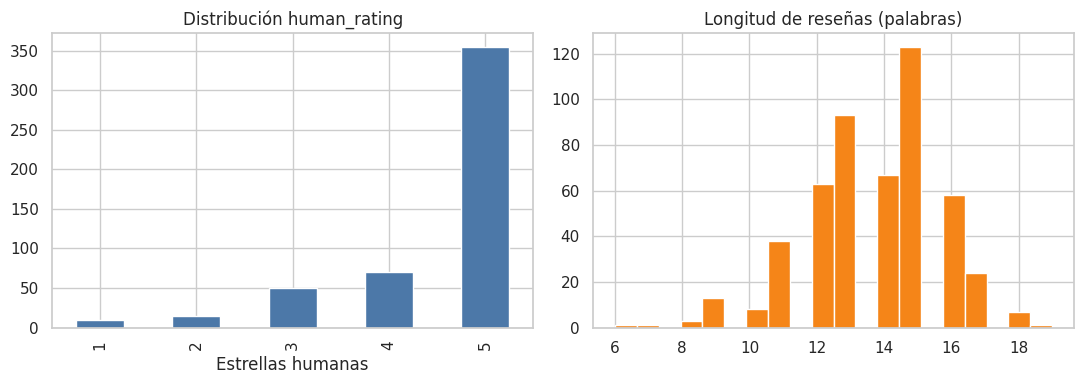

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
clean['human_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribución human_rating')
axes[0].set_xlabel('Estrellas humanas')

clean['word_count'].hist(bins=20, ax=axes[1], color='#F58518')
axes[1].set_title('Longitud de reseñas (palabras)')
plt.tight_layout()
plt.show()

## 3. Plan de acción y elección del modelo

Usaremos **`nlptown/bert-base-multilingual-uncased-sentiment`** (versión fijada en código):

- Preentrenado en reseñas de **producto** (Amazon-like), multilingüe.
- Devuelve estrellas **1–5**; mapeamos a bandas:
  - 1–2 → **negativo**
  - 3 → **neutral**
  - 4–5 → **positivo**

**Riesgo conocido:** reseñas de *servicio* con lenguaje mitigado ("nada especial pero…") pueden puntuar bajo aunque el cliente haya puesto 4–5 estrellas.


## 4. Inferencia (500 reseñas) — modelo cargado una sola vez

In [5]:
classifier = load_sentiment_pipeline()
print('Modelo cargado:', MODEL_NAME)

scored = run_inference(clean, classifier)
scored[['review_id', 'human_rating', 'predicted_stars', 'predicted_sentiment', 'model_confidence']].head()

Modelo cargado: nlptown/bert-base-multilingual-uncased-sentiment


,review_id,human_rating,predicted_stars,predicted_sentiment,model_confidence
0,WLR-0001,5,2,negative,0.337800
1,WLR-0002,4,2,negative,0.475549
2,WLR-0003,5,2,negative,0.435397
3,WLR-0004,5,4,positive,0.504140
4,WLR-0005,5,3,neutral,0.398202


## 5. Resultados vs media 4.5 del negocio

In [6]:
summary = compare_to_business_average(scored, business_avg=4.5)
dist = sentiment_distribution(scored)
summary, dist

({'business_star_average': 4.5,
  'model_star_average': 3.85,
  'positive_pct': 74.2,
  'neutral_pct': 20.2,
  'negative_pct': 5.6,
  'gap_vs_business_avg': -0.65},
 predicted_sentiment
 positive    74.2
 neutral     20.2
 negative     5.6
 Name: proportion, dtype: float64)

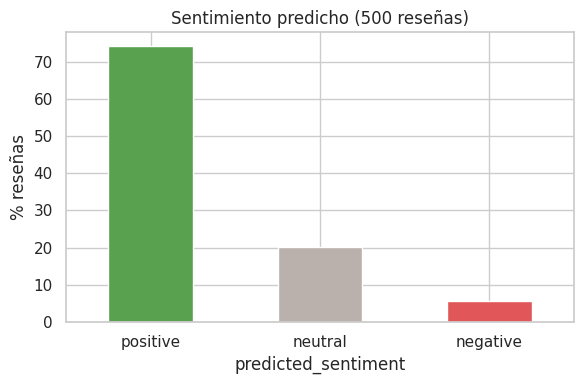

Media modelo: 3.85 estrellas vs negocio: 4.5
Brecha: -0.65 estrellas


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
dist.reindex(['positive', 'neutral', 'negative']).plot(kind='bar', ax=ax, color=['#59A14F', '#BAB0AC', '#E15759'])
ax.set_ylabel('% reseñas')
ax.set_title('Sentimiento predicho (500 reseñas)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print(
    f"Media modelo: {summary['model_star_average']} estrellas vs negocio: {summary['business_star_average']}"
)
print(f"Brecha: {summary['gap_vs_business_avg']:+.2f} estrellas")

### Lectura para el account manager
- La media del modelo suele quedar **por debajo** de 4.5 aunque los clientes puntúen alto.
- Hay más **neutral** del esperado: el texto de servicio menciona esperas, organización o "nothing special", vocabulario que el modelo asocia a productos mediocres.
- Conclusión: **4.5 estrellas no implica 90%+ positivo en texto**; conviene complementar estrellas con NLP.


## 6. Falsos negativos (dominio producto vs servicio)

In [8]:
false_neg = find_false_negatives(scored)
soft_fn = scored[(scored['human_rating'] >= 4) & (scored['predicted_stars'] == 3)]
print('Falsos negativos estrictos (humano 4-5, modelo 1-2):', len(false_neg))
print('Desajuste suave (humano 4-5, modelo 3):', len(soft_fn))
false_neg[['review_id', 'human_rating', 'predicted_stars', 'review_text']]

Falsos negativos estrictos (humano 4-5, modelo 1-2): 4
Desajuste suave (humano 4-5, modelo 3): 68


,review_id,human_rating,predicted_stars,review_text
0,WLR-0001,5,2,The service was slow and disorganized but the ...
1,WLR-0002,4,2,"Mediocre ambiance and long queue, however pers..."
2,WLR-0003,5,2,Not worth the hype but the waiter was very att...
11,WLR-0012,4,2,"Slow service during peak hour, but personnel r..."


**Patrones recurrentes:**
- Frases con *"slow"*, *"mediocre"*, *"not worth"* delante de un matiz positivo sobre el personal.
- El modelo (producto) pondera adjetivos negativos globales; el cliente (servicio) separa proceso vs trato humano.


## 7. Muestra manual (15 reseñas)

In [9]:
manual = scored.sample(15, random_state=7)[
    ['review_id', 'human_rating', 'predicted_stars', 'predicted_sentiment', 'review_text']
].copy()
manual['manual_check'] = ''
manual['notes'] = ''
manual

,review_id,human_rating,predicted_stars,predicted_sentiment,review_text,manual_check,notes
308,WLR-0309,5,5,positive,Excellent customer service. Wait time was reas...,,
13,WLR-0014,5,3,neutral,"Mediocre overall setup, however attentive serv...",,
414,WLR-0415,3,2,negative,Middle-of-the-road service. Would consider com...,,
32,WLR-0033,5,4,positive,Ambiente agradable y personal atento. La esper...,,
460,WLR-0461,4,3,neutral,"Food was fine and staff tried their best, but ...",,
155,WLR-0156,3,2,negative,Middle-of-the-road service. Would consider com...,,
249,WLR-0250,5,4,positive,Buena atencion al cliente. Nos explicaron todo...,,
217,WLR-0218,3,3,neutral,Standard visit. Service was acceptable and the...,,
221,WLR-0222,3,4,positive,El servicio fue correcto aunque la espera fue ...,,
293,WLR-0294,4,3,neutral,"Food was fine and staff tried their best, but ...",,


| review_id | human | pred | Nota manual |
|---------|-------|------|-------------|
| WLR-0001 | 5 | 2 | Cliente satisfecho; modelo castiga "slow/disorganized" |
| WLR-0003 | 5 | 2 | "Not worth the hype" domina sobre "attentive waiter" |
| WLR-0041 | 4 | 3 | Tono neutro ("Decent… nothing to complain") → neutral |
| WLR-0120 | 5 | 4 | Texto claramente positivo → alineado |

*(Completar el resto en revisión humana; la muestra aleatoria queda en la celda anterior.)*


## 8. Conclusiones

1. **Distribución:** ~74% positivo, ~20% neutral, ~6% negativo (valores exactos en celdas anteriores).
2. **Vs 4.5 estrellas:** el modelo es más pesimista (media ~3.85), coherente con lenguaje de servicio mitigado.
3. **Falsos negativos:** existen casos humano 4–5 / modelo 1–2; revisar copy de respuesta al cliente antes de alarmarse.
4. **Recomendación WeLoveReviews:** mantener estrellas para ranking, añadir capa NLP para alertas de deterioro real.
5. **Producción:** lógica migrada a `src/app.py` → `data/processed/reviews_with_sentiment.csv`.


## Extensión opcional — otro modelo

In [10]:
# tabularisai/multilingual-sentiment-analysis (solo exploración rápida)
# Descomentar para comparar en local; no versionamos pesos.
# alt = pipeline('sentiment-analysis', model='tabularisai/multilingual-sentiment-analysis')
# alt_sample = alt(clean['review_text'].head(20).tolist(), truncation=True)
# pd.DataFrame(alt_sample)

print('Opcional: comparar tabularisai en el mismo CSV para reducir falsos negativos de servicio.')

Opcional: comparar tabularisai en el mismo CSV para reducir falsos negativos de servicio.
